[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\91821\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Dataset Loaded Successfully
  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  

Number of Records:
1500

Target Classes:
<StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str

Sample Customer Messages:
779     Can you confirm whether my ticket has been ass...
1300     Please tell me how to update my account details.


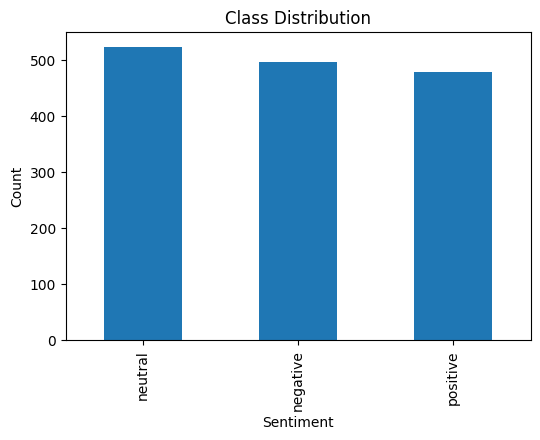


Cleaned Text Samples:
                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   
3  My refund is still pending and this experience...   
4   Please tell me how to update my account details.   

                                        cleaned_text  
0  need information payment process ticket number...  
1                   need information payment process  
2  refund process fast convenient appreciate quic...  
3  refund still pending experience frustrating ti...  
4                 please tell update account details  

TF-IDF Shape:
(1500, 146)

Why Text Must Be Converted Into Vectors:

Machine learning models only understand numerical data.

Raw text cannot be processed directly.

Vectorization converts text into numbers while preserving meaningful patterns.


Baseline Model Accuracy:
1.0

Classification Report:
         

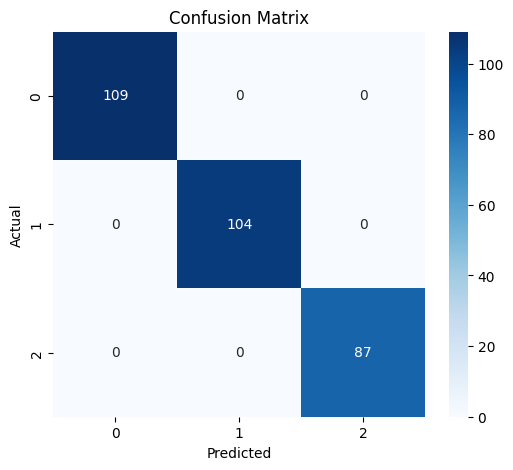


Evaluation results saved successfully.

LSTM Model Summary:


c:\Users\91821\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.3083 - loss: 1.1020 - val_accuracy: 0.3292 - val_loss: 1.0992
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.3552 - loss: 1.0996 - val_accuracy: 0.3292 - val_loss: 1.0988
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.3500 - loss: 1.0994 - val_accuracy: 0.3333 - val_loss: 1.1059
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.3427 - loss: 1.1008 - val_accuracy: 0.3292 - val_loss: 1.0989
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.3198 - loss: 1.0997 - val_accuracy: 0.3292 - val_loss: 1.0996
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3467 - loss: 1.1006

LSTM Test Accuracy:
0.3466666638851166
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step

Sample Predictions:

Message:
The issue was resolved quickly thank you
Predicted Sentiment:
neutral

Message:
I am extremely unhappy with the support
Predicted Sentiment:
neutral

Message:
Please provide an update on

In [4]:
# ============================================
# PART 3: NLP AND SEQUENCE MODELING PROJECT
# ============================================

# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense

# ============================================
# 2. DOWNLOAD NLTK RESOURCES
# ============================================

nltk.download('stopwords')

# ============================================
# 3. LOAD DATASET
# ============================================

df = pd.read_csv("customer_support_text_classification.csv")

print("Dataset Loaded Successfully")
print(df.head())

# ============================================
# TASK 1: DATASET UNDERSTANDING
# ============================================

# Number of records

print("\nNumber of Records:")
print(len(df))

# Target labels/classes

print("\nTarget Classes:")
print(df['sentiment_label'].unique())

# Sample text records

print("\nSample Customer Messages:")
print(df['customer_message'].sample(5))

# Average text length

df['text_length'] = df['customer_message'].astype(str).apply(len)

print("\nAverage Text Length:")
print(df['text_length'].mean())

# Class distribution

print("\nClass Distribution:")
print(df['sentiment_label'].value_counts())

plt.figure(figsize=(6,4))

df['sentiment_label'].value_counts().plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

# ============================================
# TASK 2: TEXT PREPROCESSING
# ============================================

stop_words = set(stopwords.words('english'))

def preprocess_text(text):

    # Convert to lowercase
    text = str(text).lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Simple tokenization (NO NLTK punkt required)
    tokens = text.split()

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Join tokens back into sentence
    return " ".join(tokens)

# Apply preprocessing

df['cleaned_text'] = df['customer_message'].astype(str).apply(preprocess_text)

print("\nCleaned Text Samples:")
print(df[['customer_message', 'cleaned_text']].head())

# ============================================
# TASK 3: TEXT VECTORIZATION
# ============================================

# TF-IDF Vectorization

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['cleaned_text'])

y = df['sentiment_label']

print("\nTF-IDF Shape:")
print(X.shape)

# ============================================
# WHY TEXT IS CONVERTED TO VECTORS
# ============================================

print("""
Why Text Must Be Converted Into Vectors:

Machine learning models only understand numerical data.

Raw text cannot be processed directly.

Vectorization converts text into numbers while preserving meaningful patterns.
""")

# ============================================
# TASK 4: BASELINE MODEL
# ============================================

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression Model

baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

# Predictions

y_pred = baseline_model.predict(X_test)

# Evaluation

accuracy = accuracy_score(y_test, y_pred)

print("\nBaseline Model Accuracy:")
print(accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ============================================
# SAVE EVALUATION RESULTS
# ============================================

evaluation_df = pd.DataFrame({
    "Metric": ["Accuracy"],
    "Value": [accuracy]
})

evaluation_df.to_csv("model_evaluation.csv", index=False)

print("\nEvaluation results saved successfully.")

# ============================================
# TASK 5: SEQUENCE MODEL
# ============================================

# Convert labels to numeric

label_mapping = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

df['label_encoded'] = df['sentiment_label'].map(label_mapping)

# Tokenizer

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['cleaned_text'])

# Convert text to sequences

sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

# Padding

max_length = 100

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post'
)

# Train-test split

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    padded_sequences,
    df['label_encoded'],
    test_size=0.2,
    random_state=42
)

# ============================================
# LSTM MODEL
# ============================================

lstm_model = Sequential()

# Embedding Layer

lstm_model.add(
    Embedding(
        input_dim=5000,
        output_dim=128,
        input_length=max_length
    )
)

# LSTM Layer

lstm_model.add(LSTM(64))

# Dense Layer

lstm_model.add(Dense(32, activation='relu'))

# Output Layer

lstm_model.add(Dense(3, activation='softmax'))

# Compile Model

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model Summary

print("\nLSTM Model Summary:")
lstm_model.summary()

# ============================================
# TRAIN LSTM MODEL
# ============================================

history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

# ============================================
# EVALUATE LSTM MODEL
# ============================================

loss, accuracy = lstm_model.evaluate(
    X_test_seq,
    y_test_seq
)

print("\nLSTM Test Accuracy:")
print(accuracy)

# ============================================
# SAMPLE PREDICTIONS
# ============================================

sample_texts = [
    "The issue was resolved quickly thank you",
    "I am extremely unhappy with the support",
    "Please provide an update on my ticket"
]

# Preprocess

sample_cleaned = [preprocess_text(text) for text in sample_texts]

# Convert to sequences

sample_sequences = tokenizer.texts_to_sequences(sample_cleaned)

# Padding

sample_padded = pad_sequences(
    sample_sequences,
    maxlen=max_length,
    padding='post'
)

# Predict

predictions = lstm_model.predict(sample_padded)

reverse_mapping = {
    0: 'negative',
    1: 'neutral',
    2: 'positive'
}

print("\nSample Predictions:")

for i, pred in enumerate(predictions):

    predicted_label = reverse_mapping[np.argmax(pred)]

    print("\nMessage:")
    print(sample_texts[i])

    print("Predicted Sentiment:")
    print(predicted_label)

# ============================================
# TASK 6: ATTENTION AND TRANSFORMERS
# ============================================

print("""
WHY RNNS STRUGGLE WITH LONG-TERM DEPENDENCIES

RNNs process text sequentially and often forget information from earlier parts
of long sequences due to vanishing gradients.

------------------------------------------------------------

HOW LSTMS HELP

LSTMs use memory cells and gating mechanisms:
- Forget Gate
- Input Gate
- Output Gate

These help preserve important information over longer sequences.

------------------------------------------------------------

WHAT ATTENTION SOLVES

Attention allows the model to focus on important words in the input sequence
instead of relying only on the final hidden state.

This improves:
- Translation
- Summarization
- Context understanding

------------------------------------------------------------

WHY TRANSFORMERS ARE IMPORTANT

Transformers use self-attention and process sequences in parallel.

Advantages:
- Faster training
- Better context understanding
- Handles long-range dependencies efficiently

Transformers power modern Generative AI models such as GPT, BERT, and LLaMA.
""")

print("\nPROJECT COMPLETED SUCCESSFULLY")

In [2]:
pip install nltk jupyter

     ---------------------------------------- 1.6/1.6 MB 2.2 MB/s eta 0:00:00
     -------------------------------------- 116.1/116.1 kB 1.1 MB/s eta 0:00:00
     -------------------------------------- 278.4/278.4 kB 1.9 MB/s eta 0:00:00
     ---------------------------------------- 78.4/78.4 kB 1.4 MB/s eta 0:00:00
     ---------------------------------------- 14.6/14.6 MB 1.7 MB/s eta 0:00:00
     -------------------------------------- 261.9/261.9 kB 1.5 MB/s eta 0:00:00
     -------------------------------------- 139.8/139.8 kB 1.7 MB/s eta 0:00:00
     -------------------------------------- 12.5/12.5 MB 907.9 kB/s eta 0:00:00
     ---------------------------------------- 2.2/2.2 MB 939.1 kB/s eta 0:00:00
     ------------------------------------ 914.9/914.9 kB 827.0 kB/s eta 0:00:00
     ---------------------------------------- 73.5/73.5 kB 1.0 MB/s eta 0:00:00
     -------------------------------------- 134.9/134.9 kB 1.6 MB/s eta 0:00:00
     -------------------------------------


[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
